In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ml libraries 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier

# Import Logging Libraries
import logging
logging.basicConfig(level = logging.INFO,
                    filename = 'model.log',
                    filemode = 'w',
                    format = '%(asctime)s -%(message)s - %(levelname)s',
                    force = True)
# Import Filter Warning Libraries
import warnings
warnings.filterwarnings(action = 'ignore')


In [2]:
df=pd.read_csv(r'C:\telecom_churn_prediction\data\churn.csv')
df.sample(frac=1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6080,9526-BIHHD,Male,0,No,No,1,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.70,29.7,Yes
7001,6304-IJFSQ,Male,0,No,No,3,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,49.90,130.1,Yes
2487,6620-HVDUJ,Male,0,No,No,24,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),60.45,1440.75,No
4185,8620-RJPZN,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,20.70,20.7,No
3578,4795-WRNVT,Female,0,No,No,40,Yes,No,DSL,Yes,...,No,No,Yes,No,Month-to-month,No,Mailed check,65.10,2586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2750,1179-INLAT,Male,0,No,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.45,69.25,No
4705,5760-FXFVO,Male,0,No,No,6,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,78.95,494.95,No
3691,2150-WLKUW,Female,0,Yes,No,40,Yes,Yes,DSL,No,...,No,No,Yes,No,One year,No,Bank transfer (automatic),63.90,2635,No
2455,8481-YYXWG,Female,0,No,No,5,Yes,No,Fiber optic,No,...,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,89.35,461.7,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("duplicated:",df.duplicated().sum())

duplicated: 0


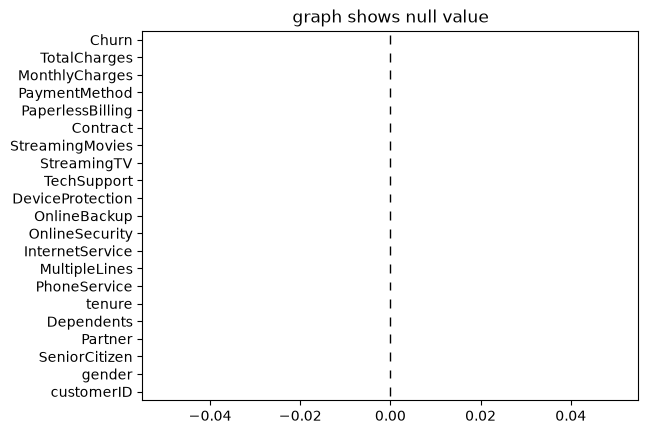

In [5]:
df.isnull().sum().plot(kind='barh',color="grey",edgecolor="k")
plt.title("graph shows null value")
plt.show()

In [6]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})


In [7]:
df['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [8]:
from collections import OrderedDict
stats=[]
for i in df.select_dtypes(exclude=object):
    numericalstats=OrderedDict({
        'feacture':i,
        'count':df[i].count(),
        'mean':df[i].mean(),
        'median':df[i].median(),
        'max':df[i].max(),
        'min':df[i].min(),
        'Q1':df[i].quantile(0.25),
        'Q3':df[i].quantile(0.75),
        'IQR':df[i].quantile(0.75)-df[i].quantile(0.25),
        'LW':(df[i].quantile(0.25)-1.5*(df[i].quantile(0.75)-df[i].quantile(0.25))),
        'UP':(df[i].quantile(0.75)+1.5*(df[i].quantile(0.75)-df[i].quantile(0.25))),
        'skew':df[i].skew(),
        'kurt':df[i].kurt()


    }) 
    stats.append(numericalstats)
    report=pd.DataFrame(stats)
report

,feacture,count,mean,median,max,min,Q1,Q3,IQR,LW,UP,skew,kurt
0,SeniorCitizen,7043,0.162147,0.00,1.00,0.00,0.0,0.00,0.00,0.000,0.000,1.833633,1.362596
1,tenure,7043,32.371149,29.00,72.00,0.00,9.0,55.00,46.00,-60.000,124.000,0.239540,-1.387372
2,MonthlyCharges,7043,64.761692,70.35,118.75,18.25,35.5,89.85,54.35,-46.025,171.375,-0.220524,-1.257260
3,Churn,7043,0.265370,0.00,1.00,0.00,0.0,1.00,1.00,-1.500,2.500,1.063031,-0.870211


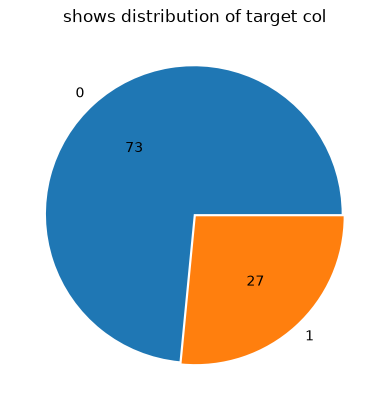

In [9]:
df['Churn'].value_counts().plot(kind='pie',autopct='%0.0f',explode=[0.01,0.01])
plt.title('shows distribution of target col')
plt.show()

In [10]:
df.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11


In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for i in df.select_dtypes(include='object'):
    df[i]=le.fit_transform(df[i])
df



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


In [12]:
df.drop(columns=['customerID'],inplace=True)


In [13]:
df.shape

(7043, 20)

In [14]:
# data preprocessing

'''
1.nature of ml=classification model
2.target col: categorical nature (yes:1,no:0)
3. before building ml model ensure dataset must be balanced
4.ensure data leackage must not happend during executin of model: if data leac found then model becomes overfit
5.overfit='fake answers',wromg ans
6.matrix for classif model are as follows
    -confusion mat
    -accurace
    -precision
    -recall
    -f1 score
    -roc and auc curve
target col mustbe bal otherwise it will give one side prediction
====================================================================
concept of preventing data leackage
1.split data into input feacture target col X and y
2.split dataset into train and test seen and unseen data
3.now use over sampling and under sampling in order to balance target column i.e bal target ol 0 nd 1
4.Building ml model 
''' 

"\n1.nature of ml=classification model\n2.target col: categorical nature (yes:1,no:0)\n3. before building ml model ensure dataset must be balanced\n4.ensure data leackage must not happend during executin of model: if data leac found then model becomes overfit\n5.overfit='fake answers',wromg ans\n6.matrix for classif model are as follows\n    -confusion mat\n    -accurace\n    -precision\n    -recall\n    -f1 score\n    -roc and auc curve\ntarget col mustbe bal otherwise it will give one side prediction\n====================================================================\nconcept of preventing data leackage\n1.split data into input feacture target col X and y\n2.split dataset into train and test seen and unseen data\n3.now use over sampling and under sampling in order to balance target column i.e bal target ol 0 nd 1\n4.Building ml model \n"

In [15]:
X=df.drop(columns = 'Churn')
y=df['Churn']

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.3,
                                               random_state=1)

In [17]:
from imblearn.over_sampling import SMOTE
sm=SMOTE()
X_train,y_train=sm.fit_resample(X_train,y_train)


In [18]:
y_train.value_counts()

Churn
0    3589
1    3589
Name: count, dtype: int64

<Axes: >

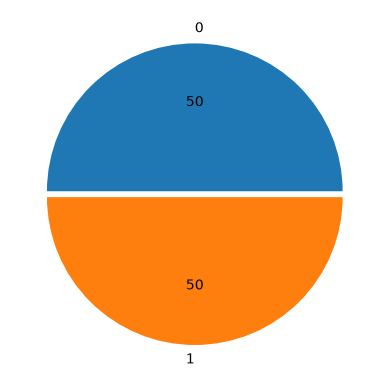

In [19]:
y_train.value_counts().plot(kind='pie',autopct='%0.0f',explode=[0.02,0.02])

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
lr=LogisticRegression().fit(X_train,y_train)

y_pred=lr.predict(X_test)

accuracyscore=accuracy_score(y_test,y_pred)
print(accuracyscore*100)

76.8575485092286


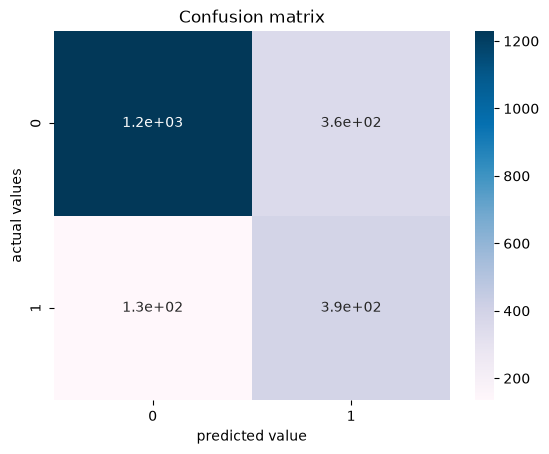

In [21]:
cf=confusion_matrix(y_test,y_pred)
sns.heatmap(cf,annot=True,cmap='PuBu')
plt.title('Confusion matrix')
plt.xlabel('predicted value')
plt.ylabel("actual values")
plt.show()

In [22]:
classificationreport=classification_report(y_test,y_pred)
print(classificationreport)

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1585
           1       0.53      0.75      0.62       528

    accuracy                           0.77      2113
   macro avg       0.71      0.76      0.73      2113
weighted avg       0.81      0.77      0.78      2113



In [ ]:
model_rf=RandomForestClassifier().fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_test)
print(classification_report(y_test,y_pred_rf)) 


              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1585
           1       0.57      0.63      0.60       528

    accuracy                           0.79      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.80      0.79      0.79      2113



In [24]:
model_dt=DecisionTreeClassifier().fit(X_train,y_train)
y_pred_dt=model_dt.predict(X_test)
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1585
           1       0.46      0.56      0.50       528

    accuracy                           0.72      2113
   macro avg       0.65      0.67      0.66      2113
weighted avg       0.75      0.72      0.73      2113



In [25]:
'''
precies matters most 
we will try to rech accuracy but we dont needed axcurcy
'''

'''
when we have more cat col and we dont know data is non normall then go for knn or svm 
in input col is more cat then numerical then knn /svm comes in role
'''

'\nwhen we have more cat col and we dont know data is non normall then go for knn or svm \nin input col is more cat then numerical then knn /svm comes in role\n'

In [26]:
'''
distance fromula underoot of (y2-y1)squre +(x2-x1)squre
knn uses eucledian and manhatten  matrix
when to use knnn when we have cat more and we dont know data is normal or nonnormal

in regression:calculates mean from all
in classif:takes neighbours
use knn and svm when we have more variance

error(act-pred)
loss=error 
error=(act-pred)
sigmoid==binary classificn
'''

'\ndistance fromula underoot of (y2-y1)squre +(x2-x1)squre\nknn uses eucledian and manhatten  matrix\nwhen to use knnn when we have cat more and we dont know data is normal or nonnormal\n\nin regression:calculates mean from all\nin classif:takes neighbours\nuse knn and svm when we have more variance\n\nerror(act-pred)\nloss=error \nerror=(act-pred)\nsigmoid==binary classificn\n'

In [27]:
from sklearn.neighbors import KNeighborsClassifier

model_knn=KNeighborsClassifier(n_neighbors=5,p=4).fit(X_train,y_train)

y_pred=model_knn.predict(X_test)

accuracyscore=accuracy_score(y_test,y_pred)
print(accuracyscore)
classificationreport=classification_report(y_test,y_pred)
print(classificationreport)


0.6914339801230478
              precision    recall  f1-score   support

           0       0.85      0.71      0.78      1585
           1       0.42      0.62      0.50       528

    accuracy                           0.69      2113
   macro avg       0.64      0.67      0.64      2113
weighted avg       0.74      0.69      0.71      2113



In [28]:
from sklearn.svm import SVC
models=({
    "knn":KNeighborsClassifier(),
    "svm":SVC()
})

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    a=accuracy_score(y_test,y_pred)
    print(a)
    b=classification_report(y_test,y_pred)
    print(b)

0.689540937056318
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      1585
           1       0.42      0.62      0.50       528

    accuracy                           0.69      2113
   macro avg       0.63      0.67      0.64      2113
weighted avg       0.74      0.69      0.71      2113



0.5707524846190251
              precision    recall  f1-score   support

           0       0.82      0.55      0.66      1585
           1       0.32      0.62      0.42       528

    accuracy                           0.57      2113
   macro avg       0.57      0.59      0.54      2113
weighted avg       0.69      0.57      0.60      2113



In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
models=({
    "knn":KNeighborsClassifier(),
    "svc":SVC()
})

for model_name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    cr=classification_report(y_test,y_pred)
    print(acc)
    print(cr)

0.689540937056318
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      1585
           1       0.42      0.62      0.50       528

    accuracy                           0.69      2113
   macro avg       0.63      0.67      0.64      2113
weighted avg       0.74      0.69      0.71      2113

0.5707524846190251
              precision    recall  f1-score   support

           0       0.82      0.55      0.66      1585
           1       0.32      0.62      0.42       528

    accuracy                           0.57      2113
   macro avg       0.57      0.59      0.54      2113
weighted avg       0.69      0.57      0.60      2113



In [ ]:
# use svm when cols are more i.e cat 
# svm makes subset of samples
# recall as well precision




